### Import libraries

In [1]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import seaborn as sns

### Overview of the data

In [2]:
data = pd.read_csv('heart.csv')

In [3]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Statistical data

In [5]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### Categorical data overview

In [6]:
categorical_data = data.select_dtypes(include=['object', 'category'])

In [7]:
for columns in categorical_data.columns:
    print(categorical_data[columns].value_counts())
    print("\n")

Sex
M    725
F    193
Name: count, dtype: int64


ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64




In [8]:
gender_counts = data['Sex'].value_counts()
fig = px.pie(values=gender_counts.values, names=gender_counts.index, title="Gender Distribution")
fig.show()

In [9]:
features = [col for col in categorical_data.columns if col != 'Sex']
n_features = len(features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig = make_subplots(rows=n_rows, cols=n_cols, subplot_titles=features)

for idx, column in enumerate(features):
    row = idx // n_cols + 1
    col = idx % n_cols + 1
    counts = categorical_data[column].value_counts()
    fig.add_trace(
        go.Bar(x=counts.index, y=counts.values, name=column, hoverinfo='x+y'),
        row=row, col=col
    )
    fig.update_xaxes(title_text=column, row=row, col=col)
    fig.update_yaxes(title_text="Count", row=row, col=col)

fig.update_layout(
    height=300 * n_rows,
    width=900,
    title_text="Categorical Feature Distributions",
    showlegend=False
)
fig.show()

In [10]:
numerical_data = data.select_dtypes(include=['number'])

In [11]:
numerical_data.corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


In [12]:
corr = numerical_data.corr()

In [13]:
fig = px.imshow(corr, color_continuous_scale='RdBu', zmin=-1, zmax=1, text_auto=True)
fig.show()

In [14]:
numerical_data.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [15]:
fig = make_subplots(rows=4, cols=2, subplot_titles=numerical_data.columns)

for i, column in enumerate(numerical_data.columns):
    row = i // 2 + 1
    col = i % 2 + 1
    fig.add_trace(
        go.Histogram(x=numerical_data[column], name=column),
        row=row, col=col
    )
    fig.update_xaxes(title_text=column, row=row, col=col)
    fig.update_yaxes(title_text="Count", row=row, col=col)

fig.update_layout(
    height=400 * n_rows,
    width=900,
    title_text="Categorical Feature Distributions",
    showlegend=False
)
fig.show()

In [16]:
fig = make_subplots(1,7,subplot_titles=numerical_data.columns)

for i, column in enumerate(numerical_data.columns):
    row = i // 7 + 1
    col = i % 7 + 1
    fig.add_trace(
        go.Box(y=numerical_data[column], name=column, boxmean='sd'),
        row=row, col=col
    )
    fig.update_xaxes(title_text=column, row=row, col=col)
    fig.update_yaxes(title_text="Value", row=row, col=col)
fig.update_layout(
    height=300 * n_rows,
    width=2500,
    title_text="Categorical Feature Distributions",
    showlegend=False
)
fig.show()

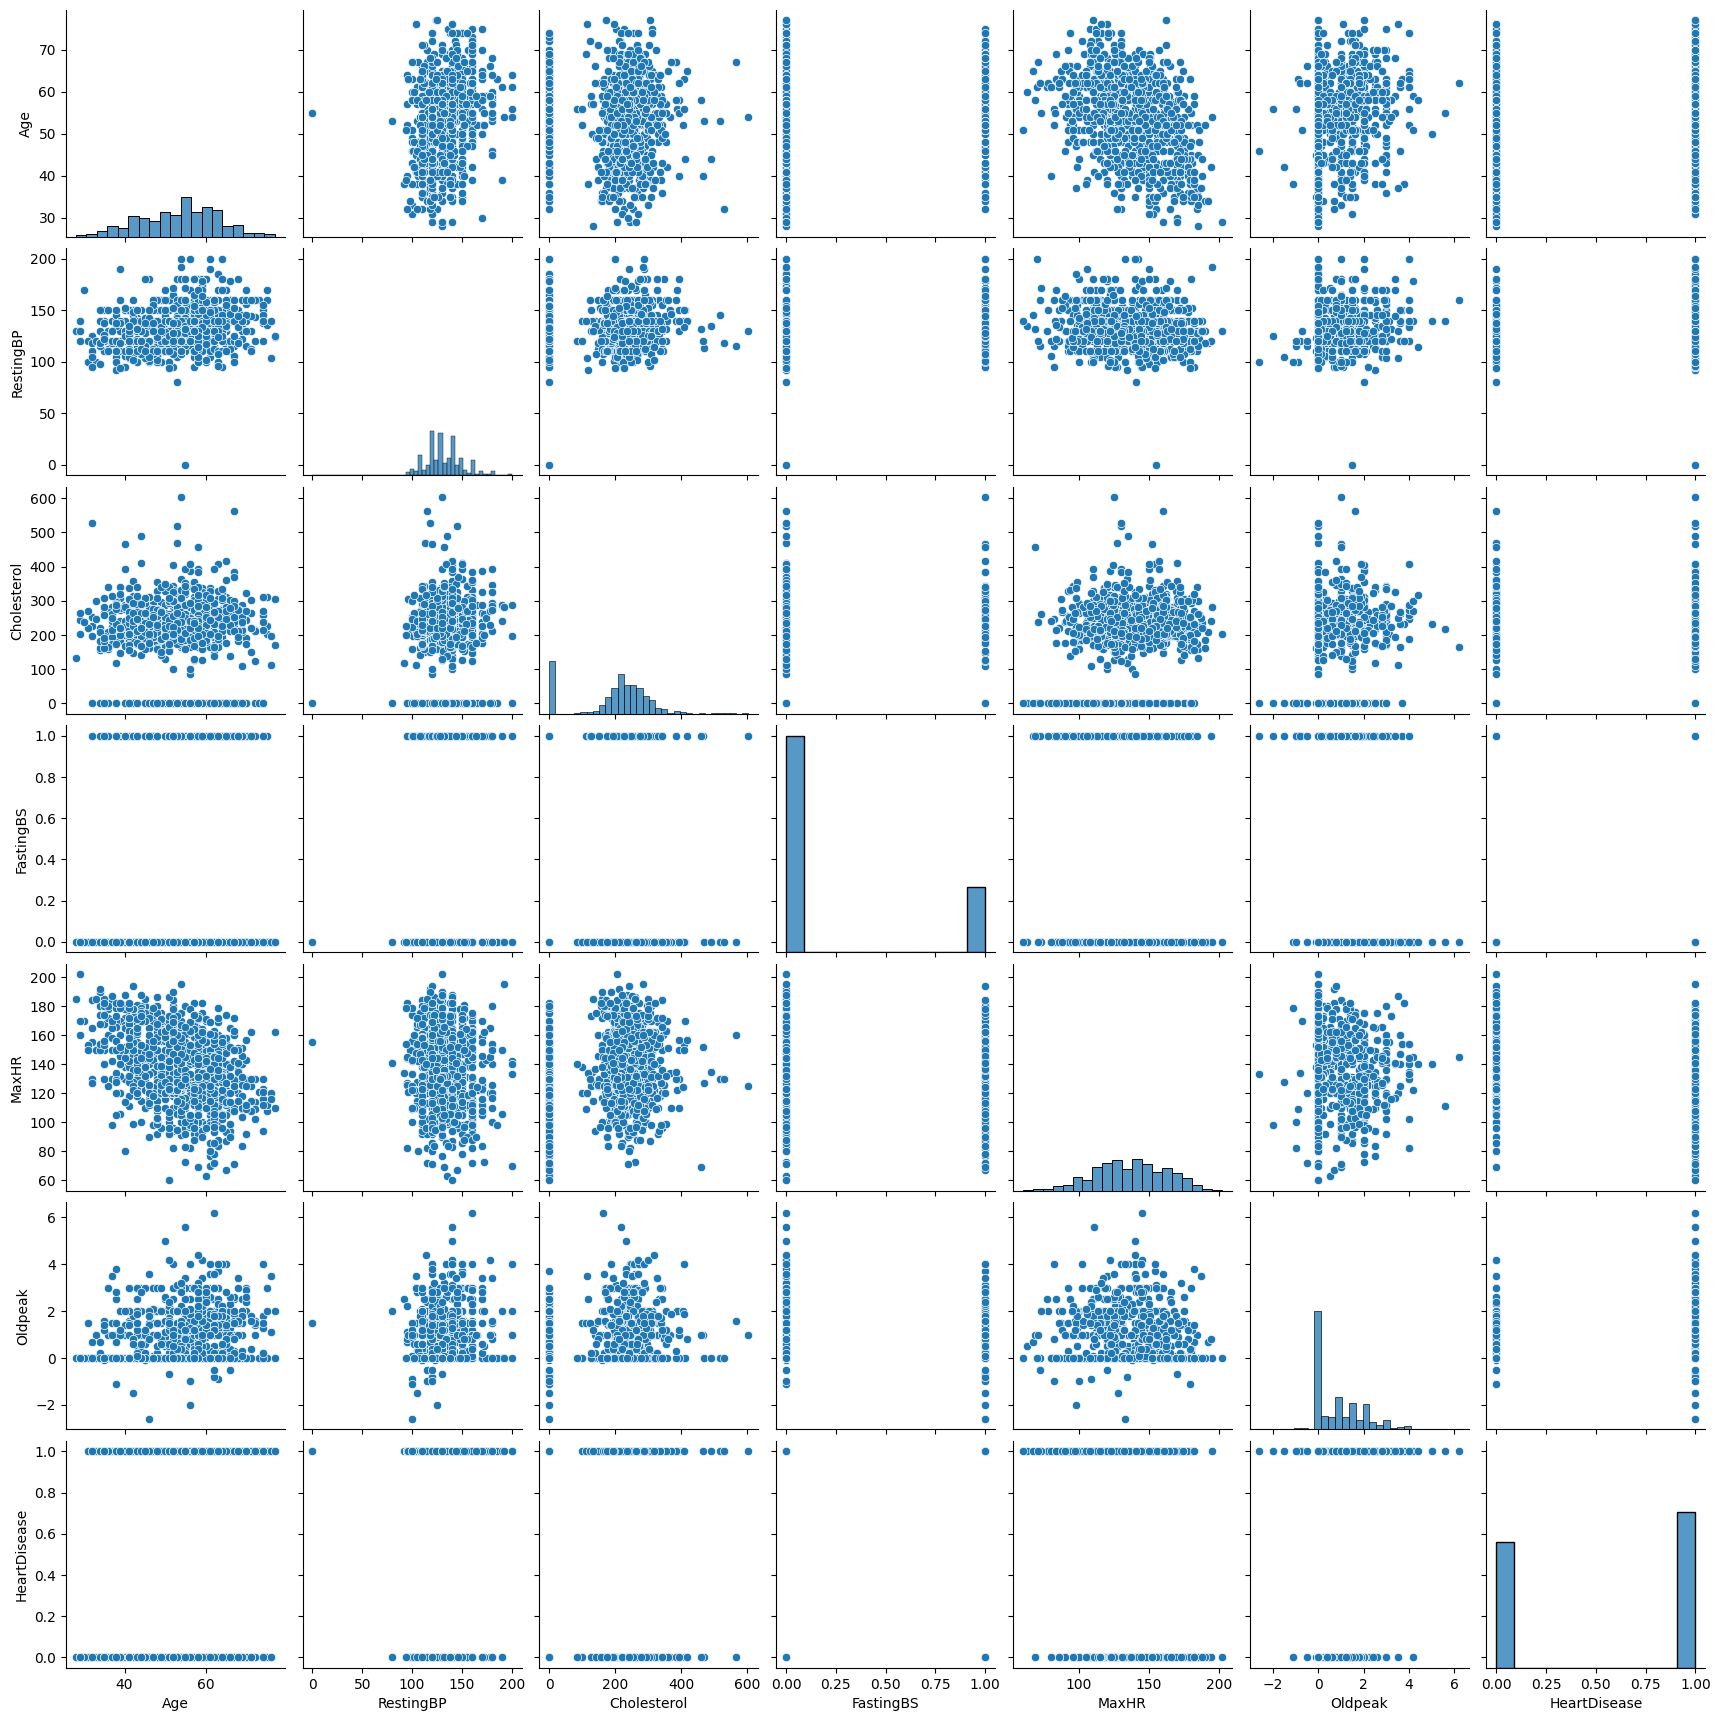

In [17]:
sns.pairplot(data)

In [18]:
round(data['HeartDisease'].value_counts()/len(data)*100,2)

HeartDisease
1    55.34
0    44.66
Name: count, dtype: float64

In [19]:
data.duplicated().sum()

0

In [20]:
data.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64